<h1>Importando bibliotecas e lendo o csv tratado

In [146]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [147]:
df = pd.read_csv("../data/processed.csv", parse_dates=["DATA"]) # parse_dates para ler a coluna DATA como datetime

In [148]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 826350 entries, 0 to 826349
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   DATA       826350 non-null  datetime64[us]
 1   CO_ID      826350 non-null  int64         
 2   CL_ID      826350 non-null  int64         
 3   CL_GENERO  826350 non-null  str           
 4   CL_EC      826350 non-null  int64         
 5   CL_FHL     826350 non-null  int64         
 6   CL_SEG     826350 non-null  str           
 7   PR_ID      826350 non-null  int64         
 8   PR_CAT     826350 non-null  str           
 9   PR_NOME    826350 non-null  str           
dtypes: datetime64[us](1), int64(5), str(4)
memory usage: 63.0 MB


<h1>Métricas estatísticas básicas sobre a coluna de filhos (CL_FHL)

In [149]:
df["CL_FHL"].describe()

count    826350.000000
mean          1.146420
std           1.416888
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max           4.000000
Name: CL_FHL, dtype: float64

In [150]:
#Calculando as métricas estatísticas manualmente
media_filhos = round(df["CL_FHL"].mean(),2)
mediana_filhos = round(df["CL_FHL"].median(),2)
moda_filhos = round(df["CL_FHL"].mode(),2)
std_filhos = round(df["CL_FHL"].std(),2)
min_filhos = df["CL_FHL"].min()
max_filhos = df["CL_FHL"].max()

# Criando um dataframe com as informações para melhorar a visualização
estatistica_filhos = pd.DataFrame({
    "Métricas": ["Média","Mediana","Moda","Desvio Padrão","Mínimo","Máximo"],
    "Valores":[media_filhos,mediana_filhos,moda_filhos[0],std_filhos,min_filhos,max_filhos]
})

estatistica_filhos


,Métricas,Valores
0,Média,1.15
1,Mediana,0.00
2,Moda,0.00
3,Desvio Padrão,1.42
4,Mínimo,0.00
5,Máximo,4.00


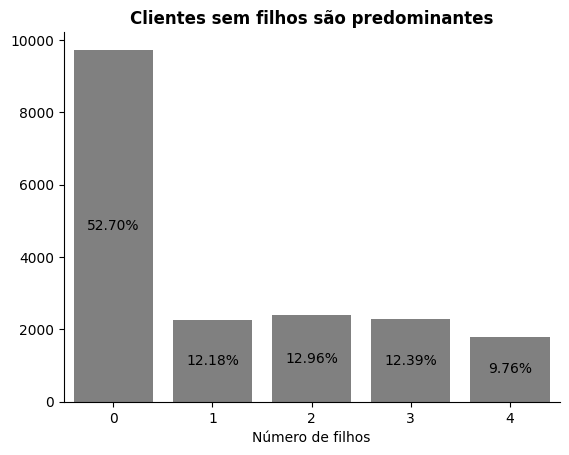

In [151]:
#Criando gráfico de barras da relação número de filhos x qtd de vendas
vendas_filhos = df.groupby(df["CL_FHL"])["CO_ID"].nunique().reset_index()

ax = sns.barplot(data = vendas_filhos, x = "CL_FHL", y="CO_ID", color="gray")

#Calculando e inserindo porcentagens no gráfico
total_vendas_filhos = vendas_filhos["CO_ID"].sum()
for barra in ax.patches: 
    altura = barra.get_height()
    percentual = (altura / total_vendas_filhos) * 100

# escreve sobre a barra
    ax.annotate( 
        f"{percentual:.2f}%",
        (barra.get_x() + barra.get_width()/2, altura/2),
        ha="center",
        va="center"
    )
    
#Configurando o gráfico
plt.title("Clientes sem filhos são predominantes", weight="bold")
plt.xlabel("Número de filhos")
plt.ylabel("")
sns.despine() # tira as bordas
plt.show()

<h4>Os clientes que não possuem filhos representam mais da metade das vendas, com 52,70% do total. Entre os clientes que possuem 1 ou mais filhos, a quantidade oscila pouco, com cada categoria se mantendo na faixa dos 12%, com excessão dos clientes com 4 filhos, que representam 9,76% do total das vendas. Percebe-se que o cliente ter filho ou não tem maior impacto do que a quantidade de filhos. 

<h3>Análise por Gênero

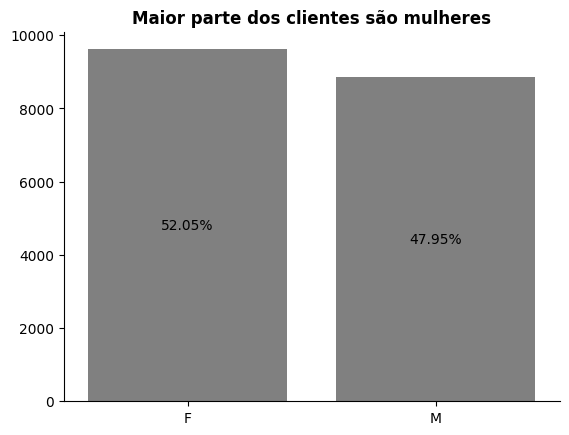

In [152]:
#Criando gráfico da relação gênero x qtd vendas
vendas_gen = df.groupby(df["CL_GENERO"])["CO_ID"].nunique().reset_index()
ax = sns.barplot(data=vendas_gen,x="CL_GENERO",y="CO_ID",color="gray")

# Calculando e inserindo no gráfico as porcentagens
total_vendas_gen = vendas_gen["CO_ID"].sum()

for barra in ax.patches: 
    altura = barra.get_height()
    percentual = (altura / total_vendas_gen) * 100
# escreve sobre a barra
    ax.annotate( 
        f"{percentual:.2f}%",
        (barra.get_x() + barra.get_width()/2, altura/2),
        ha="center",
        va="center"
    )

#Configurando o gráfico
plt.title("Maior parte dos clientes são mulheres", weight="bold")
plt.xlabel("")
plt.ylabel("")
sns.despine() # tira as bordas
plt.show()

<h1>Análise sobre as categorias de produtos

In [153]:
# Qtd de vendas por categoria
df.groupby(df["PR_CAT"])["CO_ID"].nunique().reset_index()

,PR_CAT,CO_ID
0,ACESSORIOS,9224
1,ALIMENTOS,18267
2,BEBIDAS,14735
3,HIGIENE,17610
4,LIMPEZA,17475
5,PET,13495


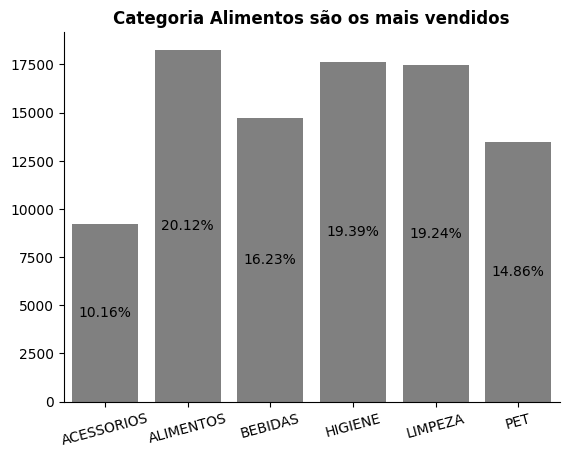

In [155]:
#Criando gráfico de barras da relação categoria de produto x qtd de vendas
vendas_categoria = df.groupby(df["PR_CAT"])["CO_ID"].nunique().reset_index()

ax = sns.barplot(data=vendas_categoria, x="PR_CAT",y="CO_ID",color="gray")

total_vendas_categoria = vendas_categoria["CO_ID"].sum()
for barra in ax.patches: 
    altura = barra.get_height()
    percentual = (altura / total_vendas_categoria) * 100

# escreve sobre a barra
    ax.annotate( 
        f"{percentual:.2f}%",
        (barra.get_x() + barra.get_width()/2, altura/2),
        ha="center",
        va="center"
    )

#Configuração do gráfico
plt.title("Categoria Alimentos são os mais vendidos", weight="bold")
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=15)
sns.despine()
plt.show()

A categoria de produtos Alimentos são os mais vendidos, com 20,12% do total, seguida das categorias Higiene (19,39%) e Limpeza (19,24%), representando, juntas, mais de 60% de todas as vendas. A categoria Acessórios possui a menor participação, com 10,16% do total. 

<h1>Análise do tempo registrado

<h3>Análise por ano

In [156]:
print(df["DATA"].min())
print(df["DATA"].max())

2019-01-04 00:00:00
2022-12-08 00:00:00


os dados registram as vendas de 2019 até 2022

In [157]:
# Quantidade de vendas realizadas por ano
df.groupby(df["DATA"].dt.year)["CO_ID"].nunique() 

DATA
2019    4483
2020    4793
2021    5504
2022    3689
Name: CO_ID, dtype: int64

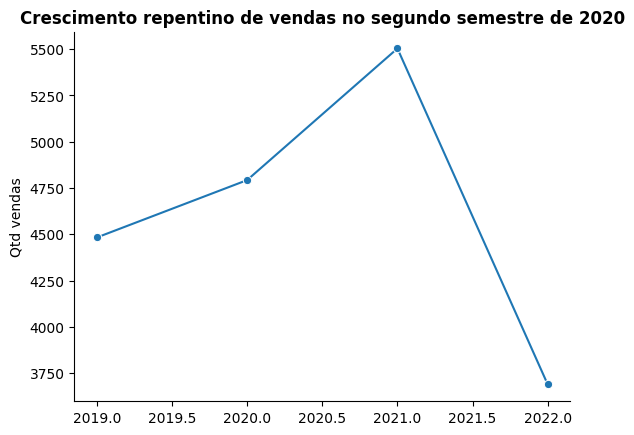

In [158]:
# Gráfico da evolução das vendas entre os anos 2019 a 2022
sns.lineplot(data=df.groupby(df["DATA"].dt.year)["CO_ID"].nunique().reset_index(), x="DATA", y= "CO_ID", marker="o")


plt.title("Crescimento repentino de vendas no segundo semestre de 2020", weight="bold")
plt.xlabel("")
plt.ylabel("Qtd vendas")
sns.despine() # tira as bordas
plt.show()

<h4>Nota-se uma grande crescente entre 2020 e 2021, seguida de uma brusca queda no ano seguinte

<h3>Análise por mês

In [159]:
# Qtd de compras por mês de todos os anos somados
df.groupby(df["DATA"].dt.month)["CO_ID"].nunique()

DATA
1     1859
2     1699
3     1442
4     1478
5     1839
6     1503
7     1533
8     1463
9     1535
10    1645
11     921
12    1552
Name: CO_ID, dtype: int64

<h4> Mês 11 (novembro) teve vendas bem abaixo dos meses restantes

In [160]:
#Novo dataframe agrupando qtd de compras por ano e mes
compras_mes = (
    df.groupby([
        df["DATA"].dt.year.rename("Ano"),
        df["DATA"].dt.month.rename("Mes")
    ])["CO_ID"]
    .nunique()
    .reset_index(name="compras")
)

#compras_mes

Text(0.5, 0.98, 'Evolução das vendas por mês de 2019 a 2022')

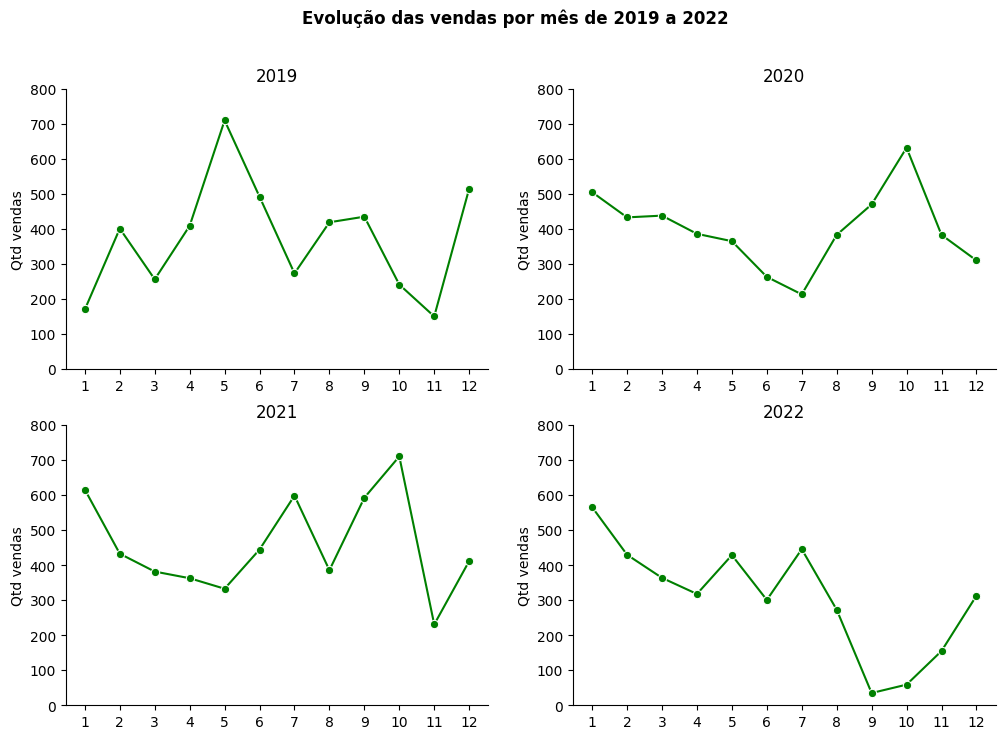

In [161]:
#Criando um quadro 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Gráficos compras por mês de cada ano
sns.lineplot(data=compras_mes[compras_mes["Ano"]==2019],x= "Mes",y="compras",marker="o", color="green",ax=axes[0,0])

sns.lineplot(data=compras_mes[compras_mes["Ano"]==2020],x= "Mes",y="compras",marker="o", color="green",ax=axes[0,1])

sns.lineplot(data=compras_mes[compras_mes["Ano"]==2021],x= "Mes",y="compras",marker="o", color="green",ax=axes[1,0])

sns.lineplot(data=compras_mes[compras_mes["Ano"]==2022],x= "Mes",y="compras",marker="o", color="green",ax=axes[1,1])

# configurando cada gráfico por loop
anos = [["2019","2020"],["2021","2022"]] # fiz como matriz para aproveitar o formato dos 2 "for" (i,j)

for i in range(2):
    for j in range(2):
        axes[i,j].set_xticks(range(1,13)) #Qtd de marcações do eixo x
        axes[i,j].set_xlabel("") # titulo eixo x
        axes[i,j].set_ylabel("Qtd vendas") # titulo eixo y
        axes[i,j].set_title(anos[i][j]) # titulo de cada gráfico
        axes[i,j].set_ylim(0, 800) # range do eixo y
        axes[i,j].set_yticks(range(0, 801, 100)) # "pulos" entre o range do eixo y - de 100 em 100
    
sns.despine()
fig.suptitle("Evolução das vendas por mês de 2019 a 2022", weight="bold") #título do quadro 2x2


<h4>Novamente nota-se uma grande queda no mês de novembro, com excessão de 2022, que houve uma grande queda no mês 9 (Setembro) mas manteve valores baixos até novembro